In [985]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

In [986]:
IMAGE_DIR = "balls"

# Folder where the .txt label files will be saved
OUTPUT_DIR = "labels"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Get all images
image_paths = sorted(
    glob.glob(os.path.join(IMAGE_DIR, "*.jpg")) +
    glob.glob(os.path.join(IMAGE_DIR, "*.jpeg")) +
    glob.glob(os.path.join(IMAGE_DIR, "*.png"))
)

print(f"Found {len(image_paths)} images")

Found 20 images


In [987]:
RED_LOWER_1 = np.array([0, 120, 70])
RED_UPPER_1 = np.array([10, 255, 255])

RED_LOWER_2 = np.array([170, 120, 70])
RED_UPPER_2 = np.array([179, 255, 255])

BLUE_LOWER = np.array([100, 50, 50])
BLUE_UPPER = np.array([140, 255, 255])

In [988]:
def create_masks(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    hsv = cv2.GaussianBlur(hsv, (3,3), 0) #gaussian blur to smoothen the image and reduce micro noise

    red_mask_1 = cv2.inRange(hsv, RED_LOWER_1, RED_UPPER_1)
    red_mask_2 = cv2.inRange(hsv, RED_LOWER_2, RED_UPPER_2)

    red_mask = cv2.bitwise_or(red_mask_1, red_mask_2)

    blue_mask = cv2.inRange(hsv,BLUE_LOWER,BLUE_UPPER)
    
    return hsv, red_mask, blue_mask

here i converted to HSV instead of RGB because it separates color from brightness so the same ball is detected whether it's in sun or shadow

In [989]:
def clean_mask(mask):
    kernal_open = np.ones((2,2), np.uint8)
    kernal_close = np.ones((7,7), np.uint8)

    mask = cv2.morphologyEx(mask,cv2.MORPH_OPEN, kernal_open, iterations=1)

    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,kernal_close, iterations=2)    

    return mask

morphological opening removes small stray noise pixels and closing fills small gaps inside the ball's mask (didn't work that well because the gaps inside the ball are very large)

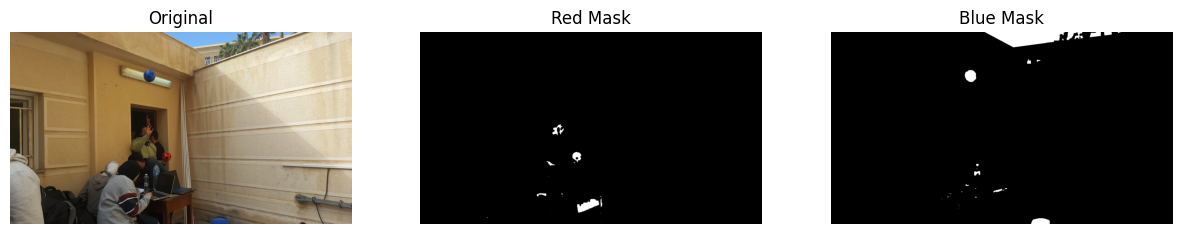

In [990]:
import random
test = random.randint(0, 20)

image = cv2.imread(image_paths[test])

hsv, red_mask, blue_mask = create_masks(image)

red_mask = clean_mask(red_mask)
blue_mask = clean_mask(blue_mask)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(red_mask, cmap="gray")
plt.title("Red Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blue_mask, cmap="gray")
plt.title("Blue Mask")
plt.axis("off")

plt.show()

In [991]:
def find_ball_candidates(mask, min_area=150):
    
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    candidates = []

    for contour in contours:

        area = cv2.contourArea(contour)

        if area < min_area:
            continue

        perimeter = cv2.arcLength(contour, True)

        # Avoid division by zero
        if perimeter == 0:
            continue

        circularity = 4 * np.pi * area / (perimeter ** 2)

        x, y, w, h = cv2.boundingRect(contour)

        candidates.append({
            "contour": contour,
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "area": area,
            "circularity": circularity
        })

    return candidates

In [992]:
def filter_ball_candidates(
    candidates,
    min_area=500,
    max_area=None,
    min_aspect=0.65,
    max_aspect=1.35,
    min_circularity=0.25
):
    
    filtered = []

    for candidate in candidates:

        x = candidate["x"]
        y = candidate["y"]
        w = candidate["w"]
        h = candidate["h"]
        area = candidate["area"]
        circularity = candidate["circularity"]

        if area < min_area:
            continue

        if max_area is not None and area > max_area:
            continue

        if h == 0:
            continue

        aspect_ratio = w / h

        if not (min_aspect <= aspect_ratio <= max_aspect):
            continue

        if circularity < min_circularity:
            continue

        candidate["aspect_ratio"] = aspect_ratio

        filtered.append(candidate)

    return filtered

detected blobs are then filtered by minimum area, aspect ratio and circularity

In [993]:
def detect_balls(image):
    
    hsv, red_mask, blue_mask = create_masks(image)

    # Clean masks
    red_mask = clean_mask(red_mask)
    blue_mask = clean_mask(blue_mask)

    # Find candidates
    red_candidates = find_ball_candidates(
        red_mask,
        min_area=1750
    )

    blue_candidates = find_ball_candidates(
        blue_mask,
        min_area=1750
    )

    # Filter candidates
    red_candidates = filter_ball_candidates(
        red_candidates
    )

    blue_candidates = filter_ball_candidates(
        blue_candidates
    )

    # 0 = Blue
    # 1 = Red

    detections = []

    for candidate in blue_candidates:
        candidate["class_id"] = 0
        detections.append(candidate)

    for candidate in red_candidates:
        candidate["class_id"] = 1
        detections.append(candidate)

    return detections, red_mask, blue_mask

In [994]:
def draw_detections(image, detections):
    
    output = image.copy()

    for detection in detections:

        x = detection["x"]
        y = detection["y"]
        w = detection["w"]
        h = detection["h"]

        class_id = detection["class_id"]

        if class_id == 0:
            label = "Blue"
            color = (255, 0, 0)   # BGR
        else:
            label = "Red"
            color = (0, 0, 255)   # BGR

        # Bounding box
        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            color,
            2
        )

        # Label
        cv2.putText(
            output,
            label,
            (x, max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

    return output

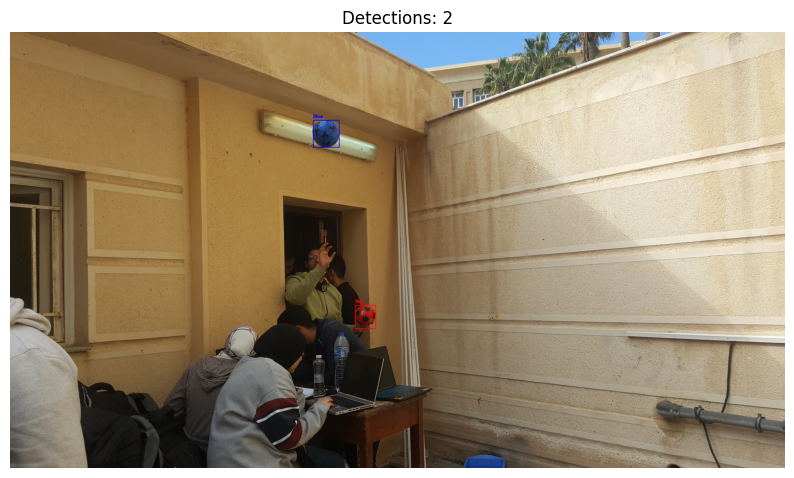

In [995]:
image = cv2.imread(image_paths[test]) #same number for debugging

detections, red_mask, blue_mask = detect_balls(image)

result = draw_detections(
    image,
    detections
)

plt.figure(figsize=(10, 8))

plt.imshow(
    cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.title(f"Detections: {len(detections)}")

plt.show()

In [996]:
def detection_to_yolo(detection, image_width, image_height):

    x = detection["x"]
    y = detection["y"]
    w = detection["w"]
    h = detection["h"]

    class_id = detection["class_id"]

    # Center coordinates
    x_center = x + w / 2
    y_center = y + h / 2

    # Normalize
    x_center /= image_width
    y_center /= image_height

    w_normalized = w / image_width
    h_normalized = h / image_height

    return (
        class_id,
        x_center,
        y_center,
        w_normalized,
        h_normalized
    )

In [997]:
def generate_yolo_labels(image, detections):

    image_height, image_width = image.shape[:2]

    lines = []

    for detection in detections:

        class_id, x_center, y_center, width, height = \
            detection_to_yolo(
                detection,
                image_width,
                image_height
            )

        line = (
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{width:.6f} "
            f"{height:.6f}"
        )

        lines.append(line)

    return lines

In [998]:
image = cv2.imread(image_paths[0])

detections, _, _ = detect_balls(image)

labels = generate_yolo_labels(
    image,
    detections
)

print("\n".join(labels))

1 0.502778 0.803125 0.198148 0.120833
1 0.652778 0.567708 0.116667 0.056250


In [999]:
for image_path in image_paths:

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        print(f"Could not read: {image_path}")
        continue

    # Detect balls
    detections, _, _ = detect_balls(image)

    # Generate YOLO labels
    labels = generate_yolo_labels(
        image,
        detections
    )

    # Create output filename
    image_name = os.path.splitext(
        os.path.basename(image_path)
    )[0]

    output_path = os.path.join(
        OUTPUT_DIR,
        image_name + ".txt"
    )

    # Write labels
    with open(output_path, "w") as f:
        f.write("\n".join(labels))

    print(
        f"{image_name}: "
        f"{len(detections)} balls detected"
    )

ball_1: 2 balls detected
ball_10: 2 balls detected
ball_11: 2 balls detected
ball_12: 0 balls detected
ball_13: 2 balls detected
ball_14: 1 balls detected
ball_15: 0 balls detected
ball_16: 2 balls detected
ball_17: 2 balls detected
ball_18: 1 balls detected
ball_19: 3 balls detected
ball_2: 2 balls detected
ball_20: 11 balls detected
ball_3: 1 balls detected
ball_4: 1 balls detected
ball_5: 2 balls detected
ball_6: 2 balls detected
ball_7: 2 balls detected
ball_8: 3 balls detected
ball_9: 0 balls detected


that is the best i could using classical CV. maybe working around morphing and circularity COULD work

If i could use DL models i would have choose hybrid approch using YOLO to detect the balls correctly then adding a HSV Mask to check the color of the ball